In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
from google.colab import files

uploaded = files.upload()

Saving heart_communication_results.csv to heart_communication_results.csv
Saving heart_fedavg_round_results.csv to heart_fedavg_round_results.csv
Saving heart_performance_results.csv to heart_performance_results.csv
Saving heart_runtime_results.csv to heart_runtime_results.csv
Saving stroke_communication_results.csv to stroke_communication_results.csv
Saving stroke_fedavg_round_results.csv to stroke_fedavg_round_results.csv
Saving stroke_performance_results.csv to stroke_performance_results.csv
Saving stroke_runtime_results.csv to stroke_runtime_results.csv


In [3]:
import os

csv_files = sorted(
    [file for file in os.listdir(".") if file.endswith(".csv")]
)

print("Uploaded CSV files:")
for file in csv_files:
    print("-", file)

print("\nTotal CSV files:", len(csv_files))

Uploaded CSV files:
- heart_communication_results.csv
- heart_fedavg_round_results.csv
- heart_performance_results.csv
- heart_runtime_results.csv
- stroke_communication_results.csv
- stroke_fedavg_round_results.csv
- stroke_performance_results.csv
- stroke_runtime_results.csv

Total CSV files: 8


In [4]:
heart_perf = pd.read_csv("heart_performance_results.csv")
stroke_perf = pd.read_csv("stroke_performance_results.csv")

heart_runtime = pd.read_csv("heart_runtime_results.csv")
stroke_runtime = pd.read_csv("stroke_runtime_results.csv")

heart_comm = pd.read_csv("heart_communication_results.csv")
stroke_comm = pd.read_csv("stroke_communication_results.csv")

heart_perf["Dataset"] = "Heart Disease"
stroke_perf["Dataset"] = "Stroke Prediction"

heart_runtime["Dataset"] = "Heart Disease"
stroke_runtime["Dataset"] = "Stroke Prediction"

heart_comm["Dataset"] = "Heart Disease"
stroke_comm["Dataset"] = "Stroke Prediction"

combined_performance = pd.concat([heart_perf, stroke_perf], ignore_index=True)
combined_runtime = pd.concat([heart_runtime, stroke_runtime], ignore_index=True)
combined_communication = pd.concat([heart_comm, stroke_comm], ignore_index=True)

print("Combined performance table")
display(combined_performance.round(4))

print("Combined runtime table")
display(combined_runtime.round(6))

print("Combined communication table")
display(combined_communication.round(4))

Combined performance table


,Method,Accuracy,Precision,Recall,F1-score,Balanced Accuracy,ROC-AUC,Dataset
0,Centralised LR,0.8333,0.8462,0.7857,0.8148,0.8304,0.9498,Heart Disease
1,Federated LR (FedAvg),0.8333,0.8462,0.7857,0.8148,0.8304,0.9509,Heart Disease
2,CKKS Encrypted Inference,0.8333,0.8462,0.7857,0.8148,0.8304,0.9498,Heart Disease
3,Centralised LR,0.7566,0.1137,0.6905,0.1953,0.7250,0.8103,Stroke Prediction
4,Federated LR (FedAvg),0.7464,0.1034,0.6429,0.1782,0.6970,0.8101,Stroke Prediction
5,CKKS Encrypted Inference,0.7566,0.1137,0.6905,0.1953,0.7250,0.8103,Stroke Prediction


Combined runtime table


,Method,Training Time (s),Inference Time (s),Encryption Time per Query (s),Decryption Time per Query (s),Total Time per Query (s),Dataset
0,Centralised LR,0.004947,0.001023,NaN,NaN,NaN,Heart Disease
1,Federated LR (FedAvg),0.744179,NaN,NaN,NaN,NaN,Heart Disease
2,CKKS Encrypted Inference,NaN,0.053711,0.019509,0.003508,0.076728,Heart Disease
3,Centralised LR,0.049593,0.003835,NaN,NaN,NaN,Stroke Prediction
4,Federated LR (FedAvg),0.299010,NaN,NaN,NaN,NaN,Stroke Prediction
5,CKKS Encrypted Inference,NaN,0.020318,0.010978,0.002073,0.033368,Stroke Prediction


Combined communication table


,Method,Communication Phase,Communication Bytes,Communication KB,Dataset
0,Federated LR (FedAvg),"Training (5 rounds, 3 hospitals)",3360,3.2812,Heart Disease
1,CKKS Encrypted Inference,Per encrypted inference query,334183,326.3506,Heart Disease
2,Federated LR (FedAvg),"Training (5 rounds, 3 hospitals)",4080,3.9844,Stroke Prediction
3,CKKS Encrypted Inference,Per encrypted inference query,334445,326.6064,Stroke Prediction


In [5]:
combined_performance.to_csv("combined_performance_results.csv", index=False)
combined_runtime.to_csv("combined_runtime_results.csv", index=False)
combined_communication.to_csv("combined_communication_results.csv", index=False)

print("Combined CSV files saved:")
print("- combined_performance_results.csv")
print("- combined_runtime_results.csv")
print("- combined_communication_results.csv")

Combined CSV files saved:
- combined_performance_results.csv
- combined_runtime_results.csv
- combined_communication_results.csv


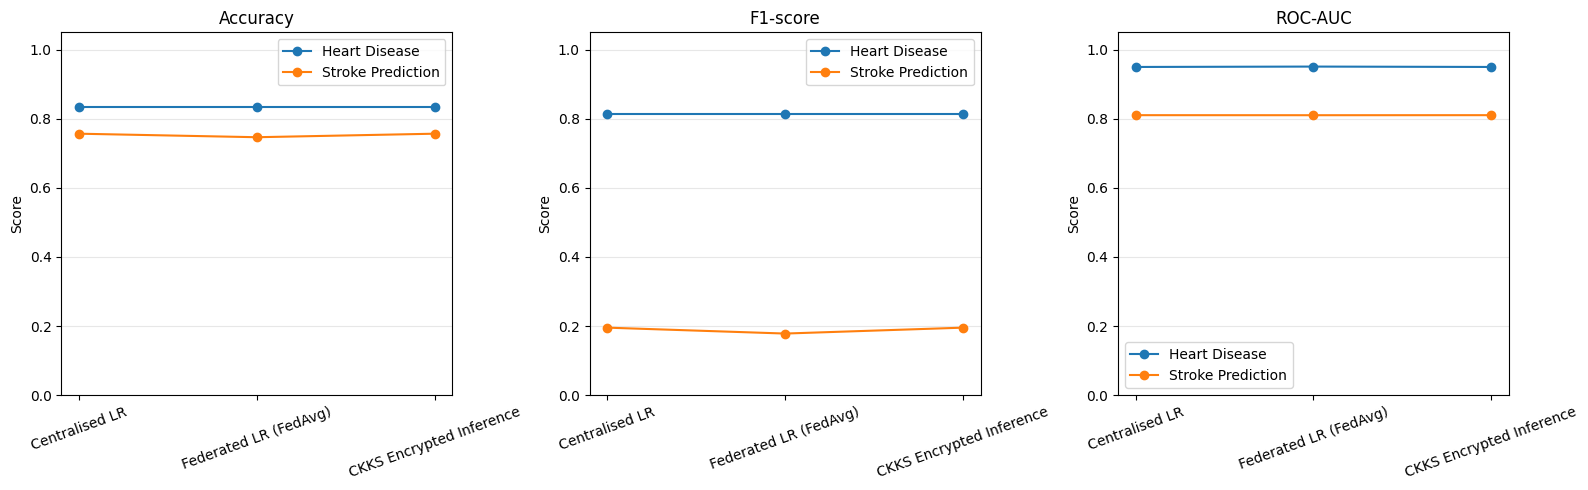

Saved: figure1_performance_comparison.png


In [7]:
# Figure 1: Accuracy, F1-score, and ROC-AUC across methods and datasets

metrics_to_plot = ["Accuracy", "F1-score", "ROC-AUC"]
methods = [
    "Centralised LR",
    "Federated LR (FedAvg)",
    "CKKS Encrypted Inference",
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metrics_to_plot):
    for dataset in ["Heart Disease", "Stroke Prediction"]:
        subset = combined_performance[
            combined_performance["Dataset"] == dataset
        ].set_index("Method").reindex(methods)

        ax.plot(
            methods,
            subset[metric],
            marker="o",
            label=dataset
        )

    ax.set_title(metric)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=20)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

plt.tight_layout()

plt.savefig(
    "figure1_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: figure1_performance_comparison.png")

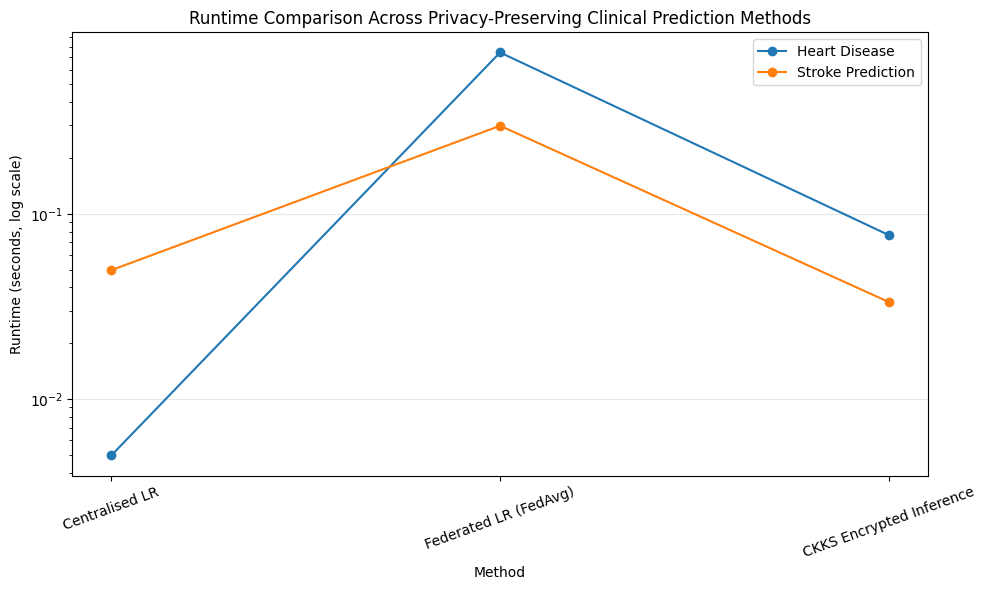

Saved: figure2_runtime_comparison.png


In [8]:
# Figure 2: Runtime comparison

runtime_plot = combined_runtime.copy()

runtime_plot["Total Runtime for Plot (s)"] = runtime_plot.apply(
    lambda row: row["Training Time (s)"]
    if not pd.isna(row["Training Time (s)"])
    else row["Total Time per Query (s)"],
    axis=1
)

plt.figure(figsize=(10, 6))

for dataset in ["Heart Disease", "Stroke Prediction"]:
    subset = runtime_plot[runtime_plot["Dataset"] == dataset]
    plt.plot(
        subset["Method"],
        subset["Total Runtime for Plot (s)"],
        marker="o",
        label=dataset
    )

plt.yscale("log")
plt.ylabel("Runtime (seconds, log scale)")
plt.xlabel("Method")
plt.title("Runtime Comparison Across Privacy-Preserving Clinical Prediction Methods")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "figure2_runtime_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: figure2_runtime_comparison.png")

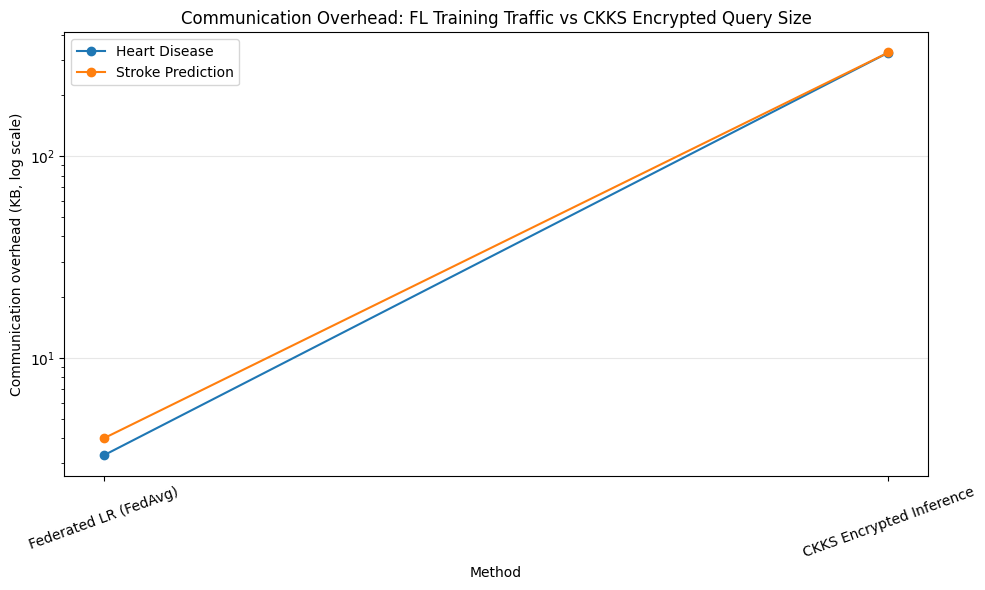

Saved: figure3_communication_overhead.png


In [9]:
# Figure 3: Communication overhead comparison

communication_plot = combined_communication.copy()

plt.figure(figsize=(10, 6))

for dataset in ["Heart Disease", "Stroke Prediction"]:
    subset = communication_plot[communication_plot["Dataset"] == dataset]
    plt.plot(
        subset["Method"],
        subset["Communication KB"],
        marker="o",
        label=dataset
    )

plt.yscale("log")
plt.ylabel("Communication overhead (KB, log scale)")
plt.xlabel("Method")
plt.title("Communication Overhead: FL Training Traffic vs CKKS Encrypted Query Size")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "figure3_communication_overhead.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: figure3_communication_overhead.png")

In [10]:
deployment_tradeoff = pd.DataFrame([
    {
        "Method": "Centralised LR",
        "Training Data Locality": "Low",
        "Inference Data Confidentiality": "Low",
        "Computation Cost": "Low",
        "Communication Cost": "Low",
        "Best Suitable Scenario": "Trusted central clinical analytics server",
    },
    {
        "Method": "Federated LR (FedAvg)",
        "Training Data Locality": "High",
        "Inference Data Confidentiality": "Moderate",
        "Computation Cost": "Moderate",
        "Communication Cost": "Moderate to High",
        "Best Suitable Scenario": "Multi-hospital collaborative model training",
    },
    {
        "Method": "CKKS Encrypted Inference",
        "Training Data Locality": "Moderate",
        "Inference Data Confidentiality": "High",
        "Computation Cost": "High",
        "Communication Cost": "High per query",
        "Best Suitable Scenario": "Privacy-preserving cloud-based inference",
    },
])

deployment_tradeoff.to_csv("deployment_tradeoff_matrix.csv", index=False)

display(deployment_tradeoff)
print("Saved: deployment_tradeoff_matrix.csv")

,Method,Training Data Locality,Inference Data Confidentiality,Computation Cost,Communication Cost,Best Suitable Scenario
0,Centralised LR,Low,Low,Low,Low,Trusted central clinical analytics server
1,Federated LR (FedAvg),High,Moderate,Moderate,Moderate to High,Multi-hospital collaborative model training
2,CKKS Encrypted Inference,Moderate,High,High,High per query,Privacy-preserving cloud-based inference


Saved: deployment_tradeoff_matrix.csv
